# Linear SVM from scratch
A NumPy implementation of the soft-margin objective
$\frac12\|w\|^2 + C\sum_i\max(0,1-y_i(w^Tx_i+b))$.
Batch subgradient steps decrease as $\eta_t=\eta_0/\sqrt{t}$, and the best observed
objective is retained. This is an educational optimizer, not a substitute for an optimized solver.
The fixed synthetic experiment uses 450 training and 150 held-out test observations.

In [1]:
from pathlib import Path
import sys

ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / 'src/svm_scratch.py').is_file()), None)
if ROOT is None:
    raise RuntimeError('Open this notebook from within its repository folder.')
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
from sklearn.datasets import make_classification
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
from sklearn.svm import LinearSVC
from src.svm_scratch import LinearSVMScratch

X, y = make_classification(n_samples=600, n_features=2, n_redundant=0,
                          n_informative=2, n_clusters_per_class=1,
                          class_sep=1.5, random_state=42)
y = np.where(y == 1, 1, -1)
train_X, test_X, train_y, test_y = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
scaler = StandardScaler().fit(train_X)
train_scaled, test_scaled = scaler.transform(train_X), scaler.transform(test_X)
print('Training and test shapes:', train_scaled.shape, test_scaled.shape)

Training and test shapes: (450, 2) (150, 2)


NumPy scratch
              precision    recall  f1-score   support

          -1       1.00      0.99      0.99        75
           1       0.99      1.00      0.99        75

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

LinearSVC (hinge)
              precision    recall  f1-score   support

          -1       1.00      0.99      0.99        75
           1       0.99      1.00      0.99        75

    accuracy                           0.99       150
   macro avg       0.99      0.99      0.99       150
weighted avg       0.99      0.99      0.99       150

Scratch iterations: 5000; best training objective: 14.1766
Objective-change stopping heuristic met: False


,implementation,test_accuracy
0,NumPy scratch,0.993333
1,LinearSVC (hinge),0.993333


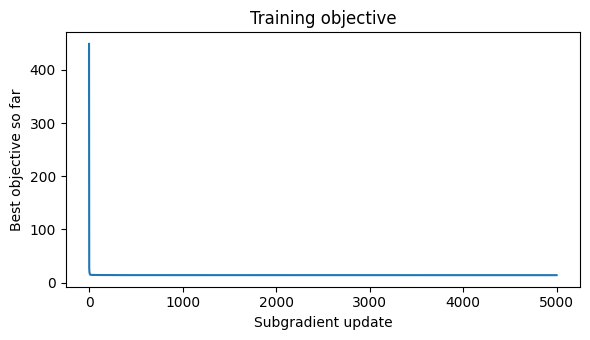

In [3]:
scratch = LinearSVMScratch(C=1.0, lr=0.01, max_iter=5000, tol=1e-7).fit(train_scaled, train_y)
reference = LinearSVC(C=1.0, loss='hinge', dual=True, max_iter=20000, random_state=42)
reference.fit(train_scaled, train_y)
results = []
for name, model in [('NumPy scratch', scratch), ('LinearSVC (hinge)', reference)]:
    predicted = model.predict(test_scaled)
    results.append({'implementation': name, 'test_accuracy': accuracy_score(test_y, predicted)})
    print(name)
    print(classification_report(test_y, predicted, zero_division=0))
display(pd.DataFrame(results))
print(f'Scratch iterations: {scratch.n_iter_}; best training objective: {scratch.best_objective_:.4f}')
print('Objective-change stopping heuristic met:', scratch.converged_)

plt.figure(figsize=(6, 3.5))
plt.plot(np.minimum.accumulate(scratch.objective_history_))
plt.xlabel('Subgradient update'); plt.ylabel('Best objective so far')
plt.title('Training objective'); plt.tight_layout(); plt.show()

Both models use hinge loss, but their optimization algorithms differ. LinearSVC also regularizes
its synthetic intercept feature, whereas the scratch implementation leaves the intercept
unregularized. Equal coefficients or probabilities are not expected; these models do not output probabilities.
Parameters above are fixed before evaluation, with no test-set tuning.

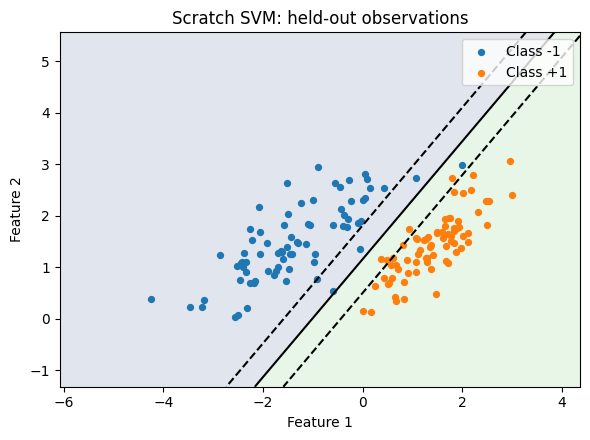

In [4]:
xx, yy = np.meshgrid(np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 200),
                     np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 200))
grid = scaler.transform(np.c_[xx.ravel(), yy.ravel()])
scores = scratch.decision_function(grid).reshape(xx.shape)
plt.figure(figsize=(6, 4.5))
plt.contourf(xx, yy, scores >= 0, alpha=0.15)
plt.contour(xx, yy, scores, levels=[-1, 0, 1], linestyles=['--', '-', '--'], colors='black')
for value in [-1, 1]:
    mask = test_y == value
    plt.scatter(test_X[mask, 0], test_X[mask, 1], s=18, label=f'Class {value:+d}')
plt.xlabel('Feature 1'); plt.ylabel('Feature 2')
plt.title('Scratch SVM: held-out observations'); plt.legend(); plt.tight_layout(); plt.show()

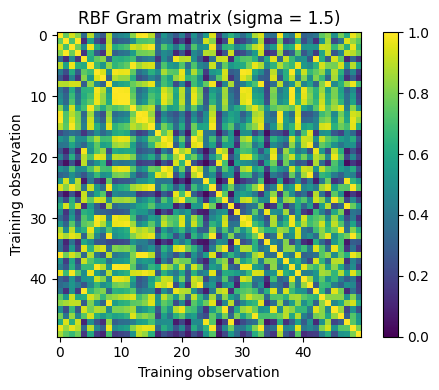

In [5]:
# Separate educational illustration: this matrix is not used to train the linear SVM.
subset = train_scaled[:50]
sigma = 1.5
squared_distances = ((subset[:, None, :] - subset[None, :, :]) ** 2).sum(axis=2)
gram = np.exp(-squared_distances / (2 * sigma ** 2))
plt.figure(figsize=(5, 4))
plt.imshow(gram, vmin=0, vmax=1)
plt.xlabel('Training observation'); plt.ylabel('Training observation')
plt.title('RBF Gram matrix (sigma = 1.5)'); plt.colorbar(); plt.tight_layout(); plt.show()